# Лабораторна робота 1 — Дослідження даних з NumPy, Pandas та scikit-learn

**Набір даних:** `kc_house_data.csv`  
**Дозволені бібліотеки:** NumPy, Pandas, Matplotlib, scikit-learn (усі модулі)

## Налаштування — встановлення залежностей та імпорт

Запустіть комірку нижче один раз, щоб переконатись, що всі необхідні пакети встановлені.

In [ ]:
# Встановлення залежностей (можна запускати повторно)
import sys
!{sys.executable} -m pip install numpy pandas matplotlib scikit-learn --quiet


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)


---
## Завдання 1 — Розминка з NumPy

**а)** Створіть масив NumPy з 10 000 значень, що підпорядковані нормальному розподілу N(0, 1). Обчисліть середнє, стандартне відхилення, мінімум і максимум за допомогою функцій NumPy — **без Python-циклів**.

**б)** Підрахуйте, скільки значень виходять за межі ±2 стандартних відхилення, використовуючи логічну індексацію. Яка це відсоткова частка? Порівняйте з теоретичним значенням ≈4,55 %.

In [ ]:
# Завдання 1а — створіть масив і обчисліть статистику
import numpy as np

arr = np.random.normal(loc=0, scale=1, size=10000)

mean = np.mean(arr)
std = np.std(arr)
min_value = np.min(arr)
max_value = np.max(arr)

print("Середнє:", mean)
print("Стандартне відхилення:", std)
print("Мінімум:", min_value)
print("Максимум:", max_value)

Середнє: -0.02556734115959565
Стандартне відхилення: 1.0081215449371885
Мінімум: -3.860193950117513
Максимум: 3.818357346048478


In [ ]:
# Завдання 1б — підрахуйте викиди за допомогою логічної індексації

outliers = arr[np.abs(arr - mean) > 2 * std]

count_outliers = len(outliers)
percentage = count_outliers / len(arr) * 100

theoretical_percentage = 4.55
difference = abs(percentage - theoretical_percentage)

print("Кількість значень за межами ±2σ:", count_outliers)
print("Відсоткова частка:", percentage, "%")
print("Теоретичне значення:", theoretical_percentage, "%")
print("Відхилення від теоретичного значення:", difference, "%")

Кількість значень за межами ±2σ: 449
Відсоткова частка: 4.49 %
Теоретичне значення: 4.55 %
Відхилення від теоретичного значення: 0.05999999999999961 %


**Ваша відповідь (б):** Практичний результат близький до теоретичного значення 4,55 %, тому розподіл даних відповідає очікуванням для нормального розподілу.


---
## Завдання 2 — Завантаження та огляд набору даних

Завантажте `kc_house_data.csv` у Pandas DataFrame та дайте відповідь на питання нижче, написавши код:

1. Скільки рядків і стовпців у наборі даних?
2. Які мінімум, максимум, середнє та медіана цін на будинки?
3. Скільки унікальних поштових індексів є у наборі даних? Який поштовий індекс має найбільше оголошень?

In [ ]:
# Завантаження набору даних
sales = pd.read_csv('kc_house_data.csv')
sales.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
# 2-і) Скільки рядків і стовпців?

rows, columns = sales.shape

print("Кількість рядків:", rows)
print("Кількість стовпців:", columns)

Кількість рядків: 21613
Кількість стовпців: 21


In [ ]:
# 2-іі) Мінімум, максимум, середнє та медіана ціни

min_price = sales["price"].min()
max_price = sales["price"].max()
mean_price = sales["price"].mean()
median_price = sales["price"].median()

print("Мінімальна ціна:", min_price)
print("Максимальна ціна:", max_price)
print("Середня ціна:", mean_price)
print("Медіана ціни:", median_price)

Мінімальна ціна: 75000.0
Максимальна ціна: 7700000.0
Середня ціна: 540088.1417665294
Медіана ціни: 450000.0


In [ ]:
# 2-ііі) Кількість унікальних поштових індексів; індекс з найбільшою кількістю оголошень

unique_zipcodes = sales["zipcode"].nunique()
most_common_zipcode = sales["zipcode"].value_counts().idxmax()

print("Кількість унікальних поштових індексів:", unique_zipcodes)
print("Поштовий індекс з найбільшою кількістю оголошень:", most_common_zipcode)

Кількість унікальних поштових індексів: 70
Поштовий індекс з найбільшою кількістю оголошень: 98103


---
## Завдання 3 — Візуалізація даних

Створіть **два графіки поруч**:

- **Лівий:** гістограма `price` (50 інтервалів, логарифмічна шкала по осі X).
- **Правий:** діаграма розсіювання `sqft_living` vs `price`, де кольором точок позначено `bedrooms`. Додайте підписи осей і colorbar.

Одним реченням для кожного графіка опишіть, що ви спостерігаєте.

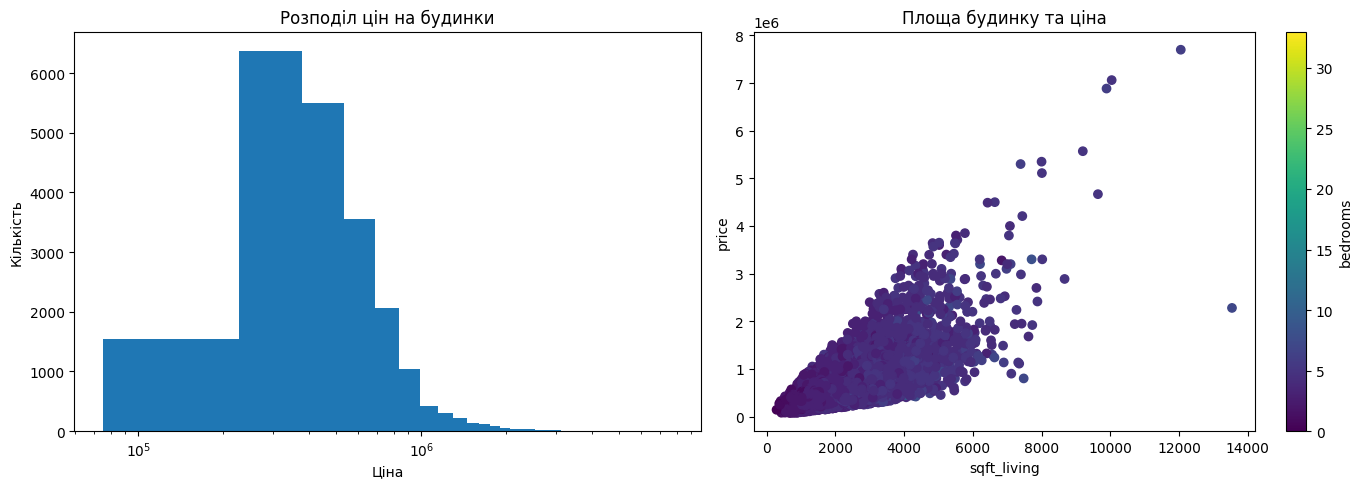

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Завдання 3 — лівий графік: гістограма ціни
axes[0].hist(sales["price"], bins=50)
axes[0].set_xscale("log")
axes[0].set_title("Розподіл цін на будинки")
axes[0].set_xlabel("Ціна")
axes[0].set_ylabel("Кількість")

# Завдання 3 — правий графік: діаграма розсіювання sqft_living vs price
scatter = axes[1].scatter(
    sales["sqft_living"],
    sales["price"],
    c=sales["bedrooms"]
)

axes[1].set_title("Площа будинку та ціна")
axes[1].set_xlabel("sqft_living")
axes[1].set_ylabel("price")

plt.colorbar(scatter, ax=axes[1], label="bedrooms")

plt.tight_layout()
plt.show()


**Спостереження (лівий графік):** Розподіл цін є правосторонньо асиметричним: більшість будинків мають відносно невисоку або середню ціну, тоді як дуже дорогі будинки зустрічаються значно рідше.


**Спостереження (правий графік):** Між житловою площею (`sqft_living`) та ціною будинку спостерігається позитивна залежність: зі збільшенням площі ціна зазвичай зростає, хоча для будинків однакової площі ціни можуть суттєво відрізнятися.


---
## Завдання 4 — Навчання та оцінка регресійної моделі

Розбийте дані 80/20 (`random_state=42`). Навчіть `LinearRegression` з scikit-learn для передбачення `price` за єдиною ознакою `sqft_living`.

1. Вкажіть вільний член (intercept) та коефіцієнт для `sqft_living`.
2. Обчисліть MSE і RMSE на тестовій вибірці.
3. Яка передбачувана ціна будинку площею 2 500 кв. футів?

In [ ]:
# Поділ на навчальну та тестову вибірки
train_data, test_data = train_test_split(sales, test_size=0.2, random_state=42)


In [ ]:
# Завдання 4 — навчіть модель, вкажіть ваги, обчисліть MSE/RMSE, передбачте ціну для 2500 кв. фут.

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

X_train = train_data[["sqft_living"]]
y_train = train_data["price"]

X_test = test_data[["sqft_living"]]
y_test = test_data["price"]

model = LinearRegression()
model.fit(X_train, y_train)

intercept = model.intercept_
coefficient = model.coef_[0]

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

predicted_price = model.predict([[2500]])[0]

print("Вільний член (intercept):", intercept)
print("Коефіцієнт для sqft_living:", coefficient)
print("MSE:", mse)
print("RMSE:", rmse)
print("Передбачувана ціна для 2500 кв. футів:", predicted_price)

Вільний член (intercept): -41999.18603993731
Коефіцієнт для sqft_living: 279.55477931526383
MSE: 76484977061.77612
RMSE: 276559.1746114674
Передбачувана ціна для 2500 кв. футів: 656887.7622482223


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


---
## Завдання 5 — Порівняння двох моделей

Навчіть другу `LinearRegression` з ознаками: `sqft_living`, `bedrooms`, `bathrooms`, `yr_built`. Порівняйте RMSE на тестовій вибірці між Моделлю 1 та Моделлю 2. Яке значення нижче? Коротко поясніть чому.

In [ ]:
# Завдання 5 — модель з чотирма ознаками та порівняння RMSE

features = ["sqft_living", "bedrooms", "bathrooms", "yr_built"]

X_train = train_data[features]
X_test = test_data[features]

y_train = train_data["price"]
y_test = test_data["price"]

model2 = LinearRegression()
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

mse2 = mean_squared_error(y_test, y_pred2)
rmse2 = np.sqrt(mse2)

print("RMSE Моделі 1:", rmse)
print("RMSE Моделі 2:", rmse2)

if rmse2 < rmse:
    print("Модель 2 має нижче RMSE.")
else:
    print("Модель 1 має нижче RMSE.")

RMSE Моделі 1: 276559.1746114674
RMSE Моделі 2: 262985.9758719034
Модель 2 має нижче RMSE.


**Відповідь:** Нижче значення RMSE має Модель 2, оскільки вона використовує більше ознак, які містять додаткову інформацію про будинок. Завдяки цьому модель може точніше описати залежність між характеристиками будинку та його ціною, що зменшує похибку прогнозування.

---
## ✨ Бонус — Аналіз залишків

Для вашої кращої моделі обчисліть вектор залишків (predicted − actual). Побудуйте гістограму. Чи виглядають залишки нормально розподіленими та центрованими навколо нуля? Що означав би систематичний ненульовий середній залишок?

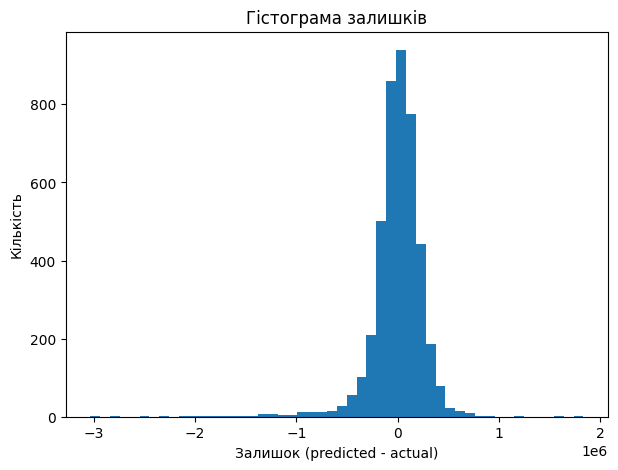

Середній залишок: -1611.51


In [ ]:
# Бонус — аналіз залишків
residuals = y_pred2 - y_test

plt.figure(figsize=(7, 5))
plt.hist(residuals, bins=50)
plt.xlabel('Залишок (predicted - actual)')
plt.ylabel('Кількість')
plt.title('Гістограма залишків')
plt.show()

print(f'Середній залишок: {residuals.mean():.2f}')

**Спостереження:**

*   Залишки мають розподіл, близький до нормального, та зосереджені навколо нуля, що свідчить про відсутність значного систематичного зміщення моделі.

*   Середній залишок становить −1611.51, тобто модель у середньому незначно недооцінює вартість будинків. Якби середній залишок був суттєво відмінним від нуля, це означало б наявність систематичної помилки прогнозування.

